# Лабораторна робота 2. Побудова лінійного бінарного класифікатора на основі оптимізації функціонала якості

### Дисципліна: Розпізнавання образів та комп'ютерний зір

### Група: КІ-22-1

### Студент: Савченко Андрій Олександрович

## Завдання для самостійної роботи

### 1. Імпортувати дані для навчальної вибірки згідно з індивідуальним варіантом (імпорт організувати з файлу).
### 2. Побудувати бінарний МНК-класифікатор згідно з розглянутим вище прикладом і вивести результати бінарної класифікації на графіку.
### 3. Проаналізувати отримані результати і порівняти їх з результатами, отриманими у лаб роб. 1.
### 4. Дати відповіді на контрольні запитання.
### 5. Відправити результати роботи у файлі lab_2_StudentLastName.ipynb до віддаленого репозиторію на GіtHub.

## Варіант індивідульного завдання

Варіант 9:
<br> x_train_9:
<br> [[14 37]
<br> [30 37]
<br> [38 13]
<br> [ 8 16]
<br> [49 47]
<br> [32 18]
<br> [28 25]
<br> [30 32]
<br> [38 17]
<br> [48 26]]
<br> y_train_9:
<br> [-1  1 -1  1 -1 -1  1 -1  1  1]

Вагові коефіцієнти: [ 1.93378248  0.01720084 -0.08491079]


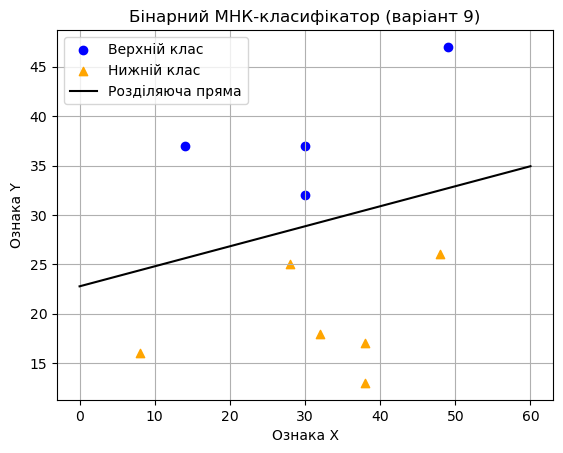

In [4]:
import numpy as np
import matplotlib.pyplot as plt

x_train = np.array([[14, 37],
                    [30, 37],
                    [38, 13],
                    [8, 16],
                    [49, 47],
                    [32, 18],
                    [28, 25],
                    [30, 32],
                    [38, 17],
                    [48, 26]])

y_train = np.array([-1, -1, 1, 1, -1, 1, 1, -1, 1, 1])

X = np.hstack((np.ones((x_train.shape[0], 1)), x_train))

w = np.linalg.inv(X.T @ X) @ X.T @ y_train

print("Вагові коефіцієнти:", w)

x_line = np.linspace(0, 60, 100)
y_line = -(w[0] + w[1] * x_line) / w[2]

plt.figure()

plt.scatter(x_train[y_train == -1][:,0],
            x_train[y_train == -1][:,1],
            color="blue",
            marker="o",
            label="Верхній клас")

plt.scatter(x_train[y_train == 1][:,0],
            x_train[y_train == 1][:,1],
            color="orange",
            marker="^",
            label="Нижній клас")

plt.plot(x_line, y_line, color="black", label="Розділяюча пряма")

plt.title("Бінарний МНК-класифікатор (варіант 9)")
plt.xlabel("Ознака X")
plt.ylabel("Ознака Y")

plt.legend()
plt.grid(True)

plt.show()

## Контрольні питання

### 1. Що таке відступ (margin) і яка його роль в побудові моделі класифікації?
Відступ (margin) - це відстань від точки до розділяючої гіперплощини.
<br> Формула: $ 𝑀_𝑖=𝑦_𝑖(𝑤^𝑇 𝑥_𝑖+𝑏) $
<br> Роль відступу:
- Показує наскільки впевнено класифікується об’єкт;
- Чим більший відступ, тим краща класифікація;
- Використовується в алгоритмах:SVM лінійних класифікаторах.
### 2. Яка роль функції втрат і чому не можна знайти коефіцієнти лінійного класифікатора шляхом безпосереднього розв’язаня задачі оптимізації через знаходження похідної?
Функція втрат показує, наскільки помиляється модель. Наприклад: $ Q(w)=∑L(M_i) $
<br> Її роль:
- Оцінює якість моделі;
- Використовується для навчання алгоритму.
<br> Чому не можна просто взяти похідну:
- Функція помилки не є диференційованою;
- Містить ступінчасті функції;
- Оптимізація є складною та нелінійною.
### 3. Чим приницпово розрізняється алгоритм, розглянутий у цій роботі від алгоритму, розглянутого у лаб. роб 1?
Тепер модель самостійно навчається знаходити параметри класифікатора.
### 4. Вивести математичний вираз для оцінки вектора?
Оцінка вектора ваг лінійного класифікатора може бути записана так: $ w=w−η∇Q(w) $
<br> Оновлення ваг для одного об’єкта: $ w=w+ηy_i x_i $ якщо об’єкт класифіковано неправильно.